# Tutorial — PBMC scATAC, start to finish

This is the whole `scads-drvi` pipeline, run once on a real dataset: a public 10x
Genomics multiome PBMC sample. Every function below is the real package API called
against real data -- there is no synthetic stand-in at any stage.

```
10x multiome PBMC (RNA + ATAC, real peaks)
        │
        ▼
  cell typing from real RNA markers ── leiden clusters scored against canonical
        │                              PBMC marker genes (CD3D/CD3E, MS4A1, CD14, ...)
        ▼
  Factorize   (scvi.external.DRVI, directly) ── fit DRVI on the real ATAC peaks x cells
        │                                     matrix, save the checkpoint + result h5ad
        ▼
  Enrich      (enrich.*, pl.enrichment)     ── real per-factor peak→SNP annotations
        │                                     against 1000G, real S-LDSC against
        │                                     Ishigaki et al. 2022 rheumatoid arthritis
        │                                     GWAS, plotted as the heritability landscape
        ▼
  Cell scores (scores.*, pl.*)              ── cs_from_z, per-cell-type summaries,
                                                the ten standard figures throughout
```

Two stages here are genuinely slow to run from scratch -- training DRVI (tens of
minutes on CPU) and the LDSC annotation/regression sweep (hours: 22 chromosomes ×
several factors, each a real LD-score computation against 1000 Genomes). Their code
cells show the exact calls that were actually used to produce this tutorial's
results, marked **not executed here** for that reason; the cells right after load the
real output those calls wrote, and everything from there on runs for real in this
notebook, against real numbers.


## 0. Get the data

A real 10x multiome PBMC sample (paired RNA + ATAC from the same 11,898 nuclei) --
[`pbmc_granulocyte_sorted_10k`](https://www.10xgenomics.com/datasets), Cell Ranger ARC
2.0.0. `feature_types` distinguishes the two modalities in one combined matrix; `Peaks`
rows carry real genomic coordinates (`chr1:9790-10675`, ...) as `var_names` directly --
already the canonical `chr:start-end` form `scads-drvi` expects a peak name in.

All one-time data provisioning -- this download, the QC/cell-typing below, the RA GWAS
sumstats, and the 1000G/baselineLD reference panel Section 3 needs -- lives in
[`prepare_data.py`](prepare_data.py), not inline here, so this notebook stays focused on
the actual pipeline calls. Every step in it is idempotent: run it as often as you like,
it only does the work that isn't already cached under `data/`.


In [1]:
import subprocess
import sys

subprocess.run([sys.executable, "prepare_data.py"], check=True)


/allen/programs/celltypes/workgroups/hct/mike.cuoco/scads_drvi/.claude/worktrees/cache-drvi-ldsc-tutorial/docs/tutorials/data/pbmc_multiome_filtered_feature_bc_matrix.h5 192.125528 MB
already prepared: /allen/programs/celltypes/workgroups/hct/mike.cuoco/scads_drvi/.claude/worktrees/cache-drvi-ldsc-tutorial/docs/tutorials/data/pbmc_rna.h5ad, /allen/programs/celltypes/workgroups/hct/mike.cuoco/scads_drvi/.claude/worktrees/cache-drvi-ldsc-tutorial/docs/tutorials/data/pbmc_atac.h5ad
already provisioned: /allen/programs/celltypes/workgroups/hct/mike.cuoco/scads_drvi/.claude/worktrees/cache-drvi-ldsc-tutorial/docs/tutorials/data/ldsc_reference/grch38_baselineLD_v2.2
already munged: /allen/programs/celltypes/workgroups/hct/mike.cuoco/scads_drvi/.claude/worktrees/cache-drvi-ldsc-tutorial/docs/tutorials/data/sumstats/ra_ishigaki2022_eur.sumstats.gz


CompletedProcess(args=['/allen/programs/celltypes/workgroups/hct/mike.cuoco/scads_drvi/.venv/bin/python', 'prepare_data.py'], returncode=0)

## 1. Split modalities, call real cell types from real markers

`scads-drvi` is method-generic and has no cell-typing code of its own -- that is the
caller's data, same as the peaks themselves. `prepare_data.py`'s `prepare_atac_rna`
does the standard scanpy work: normalize, PCA, neighbors, Leiden on the **RNA**
modality, then score each cluster against canonical PBMC marker genes and take the
top-scoring cell type per cluster. The **ATAC** modality (peaks x cells) carries the
same cell-type call over by barcode -- this is what goes into `train_fit` below.


In [2]:
import anndata as ad

rna = ad.read_h5ad("data/pbmc_rna.h5ad")
atac = ad.read_h5ad("data/pbmc_atac.h5ad")
print(f"rna {rna.shape}, atac {atac.shape}")
rna.obs["cell_type"].value_counts()


rna (11566, 21955), atac (11566, 20000)


cell_type
Monocyte    3802
CD4 T       3496
CD8 T       1550
NK          1375
B            920
DC           423
Name: count, dtype: int64

## 2. Factorize: `scvi.external.DRVI`, directly

No wrapper here: `DRVI.setup_anndata`, train, `model.save`, build the embed, write the
canonical result h5ad -- same calls as [DRVI's own
tutorial](https://drvi.readthedocs.io/latest/tutorials/external/general_pipeline.html).

Executed for real below on a GPU (`accelerator="gpu"`) -- a few minutes for 200 epochs
over ~11.5k cells x 20k peaks, vs. much longer on CPU. To keep the rest of this
notebook reproducible against the canonical `data/pbmc_result.h5ad` -- the fit whose
factors already have a validated, hours-long S-LDSC sweep behind them in
`data/enrich_results` -- this GPU run's checkpoint and embedding are written to
separate `*_gpu` paths rather than overwriting that canonical output. Section 2's
diagnostics onward keep loading the canonical fit.

The checkpoint at `data/pbmc_model_gpu` doubles as a cache: re-running this cell after
the first time loads it with `DRVI.load` instead of re-training, so the notebook can be
explored interactively without repeating the fit. Delete that directory to force a
fresh fit.


In [3]:
from pathlib import Path

import anndata as ad
import scvi
from scvi.external import DRVI

MODEL_DIR = "data/pbmc_model_gpu"

scvi.settings.seed = 0
DRVI.setup_anndata(atac, batch_key=None)

if Path(MODEL_DIR).exists():
    # Cached from a previous run of this cell -- load instead of re-training so the
    # rest of the notebook can be explored interactively without repeating the fit.
    model = DRVI.load(MODEL_DIR, adata=atac)
else:
    model = DRVI(atac, n_latent=32)
    # check_val_every_n_epoch=1 -- off by default (scvi-tools only checks validation when
    # early stopping or checkpointing is on), needed here so elbo/reconstruction_loss's
    # validation curves are populated in model.history alongside train below.
    model.train(
        max_epochs=200, batch_size=256, accelerator="gpu", devices=1,
        check_val_every_n_epoch=1,
    )
    model.save(MODEL_DIR, overwrite=True)

embed_gpu = ad.AnnData(
    model.get_latent_representation(atac),
    obs=atac.obs[["cell_type", "n_genes_by_counts", "total_counts"]].copy(),
)
# dim_0..dim_{K-1} -- the canonical var_names convention every result h5ad uses (see
# the getting-started guide); AnnData's own default ("0", "1", ...) would otherwise
# leave this fit's var index inconsistent with the canonical embed loaded below.
embed_gpu.var_names = [f"dim_{i}" for i in range(embed_gpu.n_vars)]
model.set_latent_dimension_stats(embed_gpu, vanished_threshold=0.5)

# A fit's results are one AnnData, written with a plain write_h5ad call -- no wrapper.
embed_gpu.uns["provenance"] = {
    "n_latent": 32, "batch_key": None, "model_dir": MODEL_DIR,
    "seed": 0, "accelerator": "gpu",
}
embed_gpu.write_h5ad("data/pbmc_result_gpu.h5ad")


/allen/programs/celltypes/workgroups/hct/mike.cuoco/scads_drvi/.venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


[rank: 0] Seed set to 0


INFO     File data/pbmc_model_gpu/model.pt already downloaded                                                      


/allen/programs/celltypes/workgroups/hct/mike.cuoco/scads_drvi/.venv/lib/python3.13/site-packages/lightning/fabric/plugins/environments/slurm.py:204: The `srun` command is available on your system but is not used. HINT: If your intention is to run Lightning on SLURM, prepend your python command with `srun` like so: srun python /allen/programs/celltypes/workgroups/hct/mike.cuoco/ ...


INFO     The model has been initialized                                                                            


  0%|          | 0/91 [00:00<?, ?it/s]

100%|██████████| 91/91 [00:02<00:00, 32.23it/s]

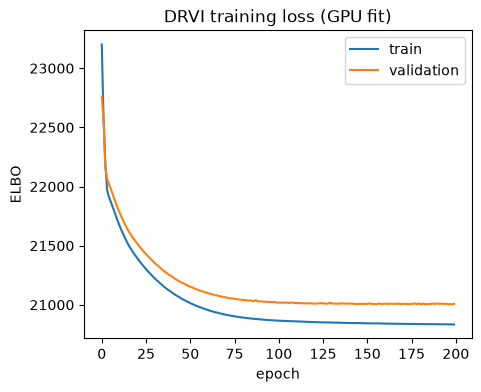

In [4]:
import matplotlib.pyplot as plt

# reconstruction_loss tracks elbo almost exactly here -- KL's contribution to the
# total is small relative to reconstruction -- so just the loss actually being
# optimized (ELBO) is shown, not both.
fig, ax = plt.subplots(figsize=(5, 4))
for split in ("train", "validation"):
    key = f"elbo_{split}"
    if key in model.history:
        # .iloc[:, 0] -- a bare single-column DataFrame ignores plot()'s `label`
        # kwarg and falls back to the column name (e.g. "elbo_train") instead.
        model.history[key].iloc[:, 0].plot(ax=ax, label=split)
ax.set_xlabel("epoch")
ax.set_ylabel("ELBO")
ax.set_title("DRVI training loss (GPU fit)")
ax.legend()
fig;


In [5]:
import anndata as ad

embed = ad.read_h5ad("data/pbmc_result.h5ad")
embed


AnnData object with n_obs × n_vars = 11566 × 32
    obs: 'cell_type', 'n_genes_by_counts', 'total_counts'
    var: 'original_dim_id', 'reconstruction_effect', 'order', 'max_value', 'mean', 'min', 'max', 'std', 'std_abs', 'title', 'vanished', 'vanished_positive_direction', 'vanished_negative_direction'
    uns: 'cell_type_colors', 'enrich', 'provenance'
    obsm: 'X_umap'
    layers: None (.X)

`embed.var` carries DRVI's own per-dimension statistics
(`model.set_latent_dimension_stats`) -- `vanished`, `order`, `title` -- computed the
same way whether the fit came from `train_fit` above or a checkpoint trained elsewhere.


In [6]:
print(f"{int(embed.var['vanished'].sum())} of {embed.n_vars} dimensions vanished")
embed.var[["vanished", "order"]].sort_values("order").head(10)


0 of 32 dimensions vanished


,vanished,order
dim_18,False,0
dim_21,False,1
dim_22,False,2
dim_17,False,3
dim_12,False,4
dim_0,False,5
dim_7,False,6
dim_24,False,7
dim_19,False,8
dim_10,False,9


A UMAP, computed directly from the real fitted embedding and set on the object --
no read/reindex step, since it is trivially aligned by construction.


In [7]:
import scanpy as sc

# A throwaway copy for the neighbors graph -- only its X_umap coordinates get kept on
# `embed` itself, so the neighbors graph never leaks into the canonical result h5ad
# written back to disk in Section 3.
_tmp = embed.copy()
sc.pp.neighbors(_tmp, n_neighbors=15)
sc.tl.umap(_tmp, min_dist=0.3, spread=1.0)
embed.obsm["X_umap"] = _tmp.obsm["X_umap"]
del _tmp


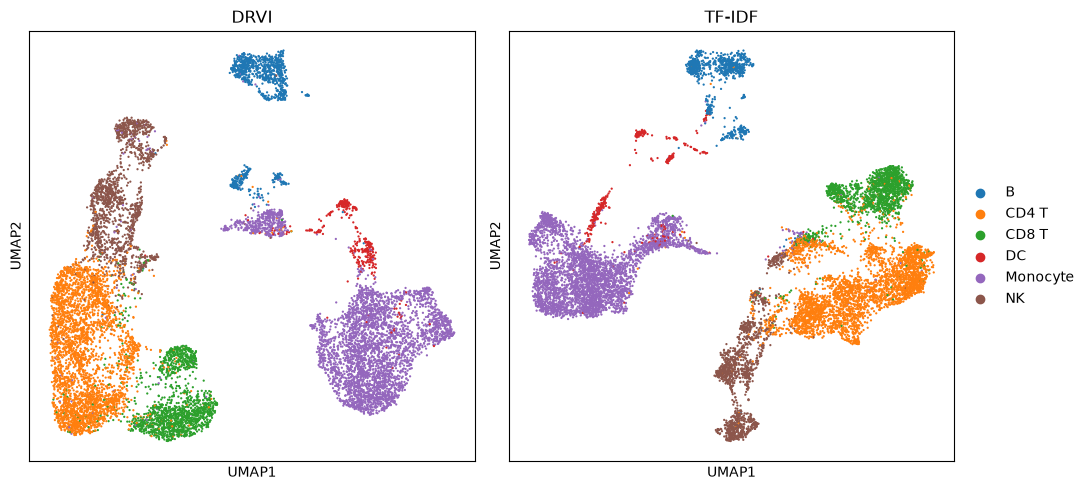

In [8]:
import matplotlib.pyplot as plt
import numpy as np
import scanpy as sc

cells = embed.obs.copy()


def tfidf(X):
    """Log(TF)-log(IDF) -- Signac's default, same as muon.atac.pp.tfidf's defaults."""
    tf = X.multiply(1 / X.sum(axis=1)).tocsr()
    tf.data = np.log1p(tf.data * 1e4)
    idf = np.log1p(np.asarray(X.shape[0] / X.sum(axis=0))).ravel()
    return tf.multiply(idf).tocsr()


# The standard scATAC linear baseline -- TF-IDF, then PCA/SVD directly on the
# resulting sparse matrix with no mean-centering (i.e. LSI) -- on the exact same
# peaks x cells matrix DRVI was trained on. One extra component is computed
# (n_comps=33) so the first can be dropped before neighbors/UMAP -- it routinely just
# tracks sequencing depth rather than biology (the same reason Signac/ArchR drop it by
# default) -- leaving 32 components, DRVI's own n_latent.
atac_tfidf = atac.copy()
atac_tfidf.X = tfidf(atac_tfidf.X)
sc.pp.pca(atac_tfidf, n_comps=33, zero_center=False)
atac_tfidf.obsm["X_pca"] = atac_tfidf.obsm["X_pca"][:, 1:]
sc.pp.neighbors(atac_tfidf, n_neighbors=15)
sc.tl.umap(atac_tfidf, min_dist=0.3, spread=1.0)

# One shared cell_type legend -- both panels share the same categories/colors, so the
# left panel's would-be copy is dropped rather than shown twice.
fig, axes = plt.subplots(1, 2, figsize=(11, 5))
sc.pl.embedding(
    embed, basis="umap", color="cell_type", ax=axes[0], show=False, title="DRVI",
    legend_loc=None,
)
sc.pl.embedding(
    atac_tfidf, basis="umap", color="cell_type", ax=axes[1], show=False, title="TF-IDF",
)
fig.tight_layout()
fig;

Every dimension `scads-drvi` keeps gets its own diagnostics -- how it correlates with its neighbours, whether it tracks a nuisance covariate, its own summary statistics, what it looks like spatially, and how its value varies across cell types. All of `pl.umap`/`pl.factors`'s figures are in-house (wrapping `scanpy.pl.embedding` where an embedding is involved), so none of this needs a `drvi-py` install:

In [9]:
embed.obs

,cell_type,n_genes_by_counts,total_counts
AAACAGCCAAGGAATC-1,CD4 T,16515,60810.0
AAACAGCCAATCCCTT-1,CD4 T,8885,23781.0
AAACAGCCAATGCGCT-1,CD4 T,8168,19975.0
AAACAGCCACACTAAT-1,CD8 T,651,1437.0
AAACAGCCACCAACCG-1,CD8 T,4227,9289.0
...,...,...,...
TTTGTTGGTGACATGC-1,CD8 T,7114,18812.0
TTTGTTGGTGTTAAAC-1,CD8 T,8023,19768.0
TTTGTTGGTTAGGATT-1,NK,5475,12537.0
TTTGTTGGTTGGTTAG-1,CD4 T,7993,20626.0


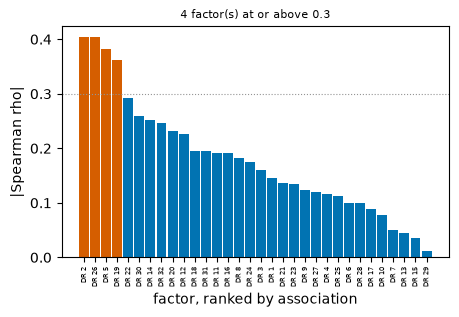

In [10]:
import pandas as pd
from scipy.stats import spearmanr

from scads_drvi.pl.factors import covariate_association

# Does any factor just track sequencing depth rather than biology? Labeled by DRVI's
# own "DR N" title, not the raw dim_N index -- see factor_correlation below.
covariate = embed.obs["n_genes_by_counts"].to_numpy(dtype=float)
rho = pd.Series(
    [spearmanr(embed.X[:, j], covariate).statistic for j in range(embed.n_vars)],
    index=embed.var["title"],
)
fig, _ = covariate_association(rho, threshold=0.3)
fig;

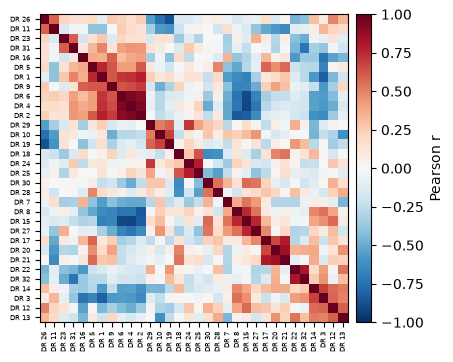

In [11]:
import pandas as pd

from scads_drvi.pl.factors import factor_correlation

# Labeled by DRVI's own "DR N" title, not the raw dim_N index -- the same convention
# latent_umap_grid/latent_heatmap already display factors under.
signed_loadings = pd.DataFrame(embed.X, index=embed.obs_names, columns=embed.var["title"])
vanished_titles = embed.var.loc[embed.var["vanished"], "title"]

fig, _ = factor_correlation(signed_loadings.corr(), vanished=vanished_titles)
fig;

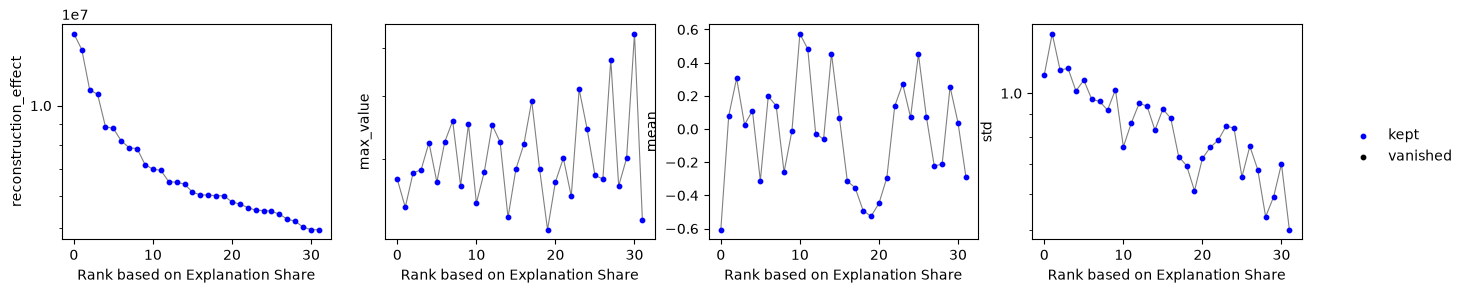

In [12]:
from scads_drvi.pl.factors import latent_dimension_stats

fig, _ = latent_dimension_stats(embed.var)
fig;

/allen/programs/celltypes/workgroups/hct/mike.cuoco/scads_drvi/src/scads_drvi/pl/umap.py:181: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  plotted = ad.concat([pos, neg], axis=1, join="inner", merge="first")


/allen/programs/celltypes/workgroups/hct/mike.cuoco/scads_drvi/src/scads_drvi/pl/umap.py:214: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator. Otherwise, ticks may be mislabeled.
  ax.set_yticklabels(labels)
/allen/programs/celltypes/workgroups/hct/mike.cuoco/scads_drvi/src/scads_drvi/pl/umap.py:214: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator. Otherwise, ticks may be mislabeled.
  ax.set_yticklabels(labels)
/allen/programs/celltypes/workgroups/hct/mike.cuoco/scads_drvi/src/scads_drvi/pl/umap.py:214: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator. Otherwise, ticks may be mislabeled.
  ax.set_yticklabels(labels)
/allen/programs/celltypes/workgroups/hct/mike.cuoco/scads_drvi/src/scads_drvi/pl/umap.py:214: UserWarning: set_ticklabels() should only be 

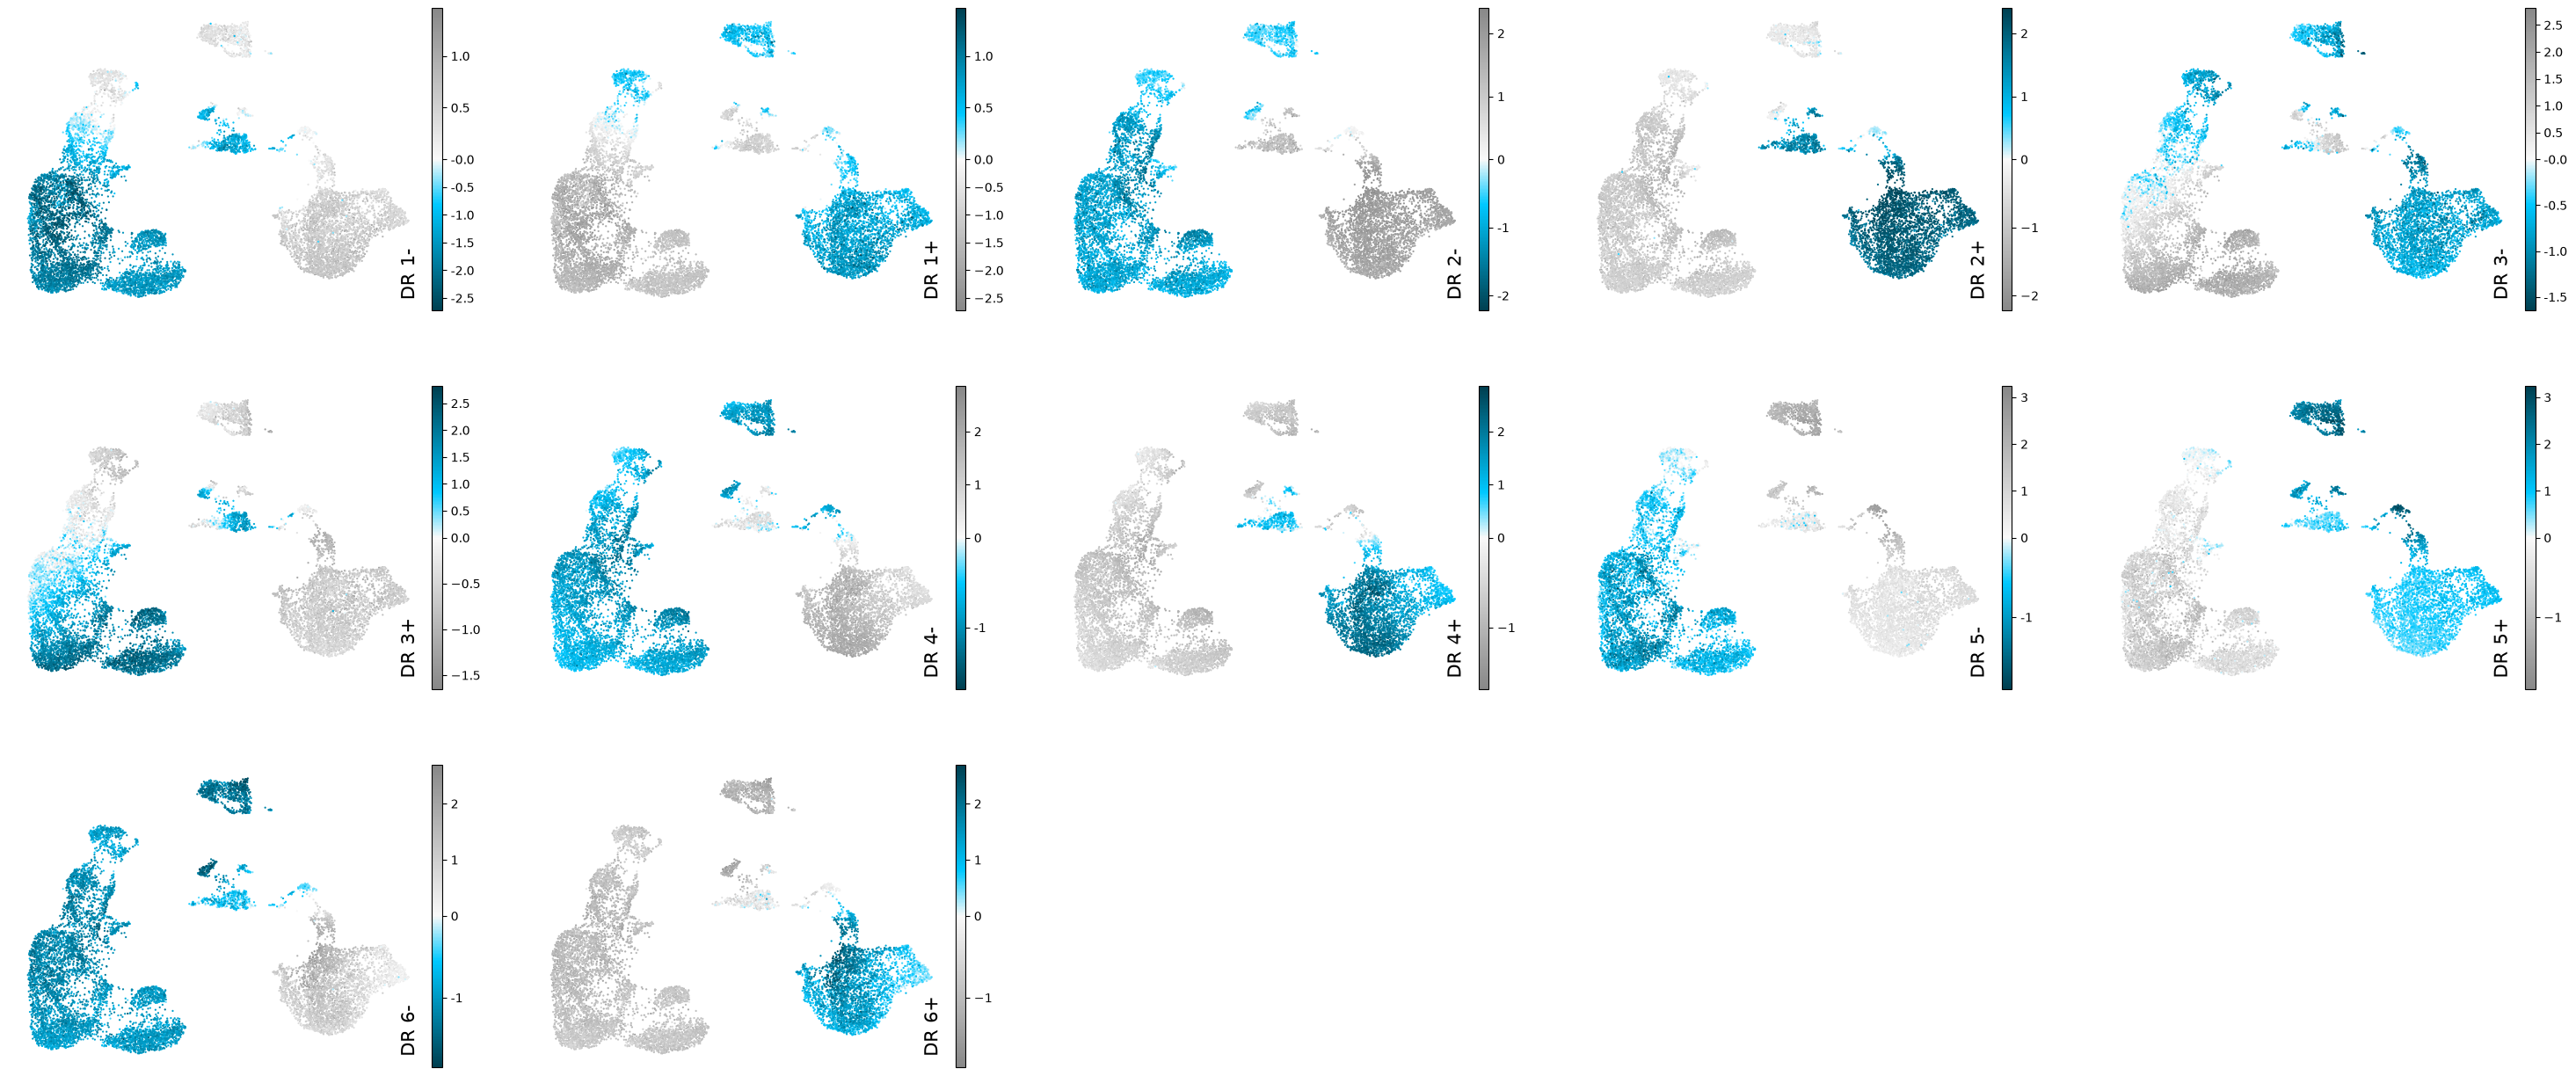

In [13]:
from scads_drvi.pl.umap import latent_umap_grid

# A compact subset for a readable grid -- the first six by DRVI's own rank.
# directional=True is the default -- each dimension gets its own +/- panel pair (12
# panels total for six dims), not just one panel per dimension.
first_six = list(embed.var.sort_values("order").index[:6])
fig = latent_umap_grid(embed, dim_subset=first_six)
fig;

/allen/programs/celltypes/workgroups/hct/mike.cuoco/scads_drvi/.venv/lib/python3.13/site-packages/scanpy/plotting/_utils.py:509: ImplicitModificationWarning: Trying to modify attribute `._uns` of view, initializing view as actual.
  adata.uns[f"{value_to_plot}_colors"] = colors_list


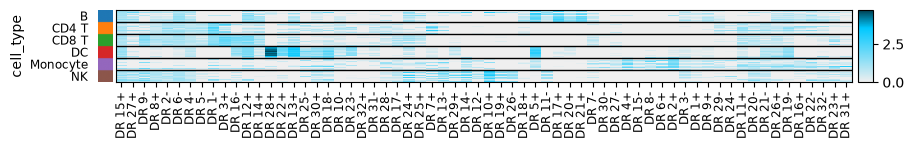

In [14]:
from scads_drvi.pl.factors import latent_heatmap

# order="cluster" here (vs. the default "rank") -- grouped by which cells drive
# similar factors, not by DRVI's explained-share ranking. directional=True is also
# the default (unset here): every kept dimension becomes two columns, its own ReLU'd
# positive and negative parts, not one.
fig, _ = latent_heatmap(embed, "cell_type", order="cluster")
fig;

/allen/programs/celltypes/workgroups/hct/mike.cuoco/scads_drvi/.venv/lib/python3.13/site-packages/scanpy/plotting/_utils.py:509: ImplicitModificationWarning: Trying to modify attribute `._uns` of view, initializing view as actual.
  adata.uns[f"{value_to_plot}_colors"] = colors_list


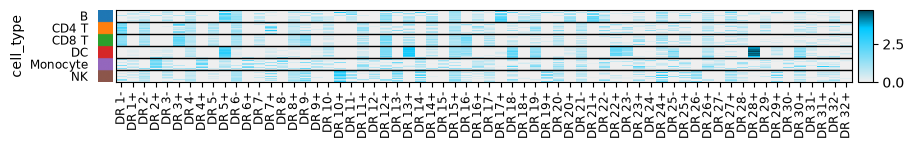

In [15]:
# The default order="rank" instead -- DRVI's own explained-share ranking, not the
# correlation-driven grouping above. directional=True (also the default, unset here)
# still splits every dimension into its own +/- columns either way.
fig, _ = latent_heatmap(embed, "cell_type")
fig;

## 3. Enrich: real peaks → real S-LDSC against a real rheumatoid arthritis GWAS

`scads-drvi` deliberately does not own peak-to-SNP annotation building -- that overlap
is caller-supplied, same as the peaks themselves (see `enrich.config`'s module
docstring). RA is a genuinely well-powered choice for a PBMC (peripheral immune cell) fit: its genetic architecture is one of the most consistently replicated immune/T-cell heritability enrichments in the S-LDSC literature, unlike Alzheimer's disease (tried first here), whose risk concentrates in brain microglia rather than peripheral blood monocytes -- a real reason peripheral PBMC factors showed no significant enrichment for it. The real annotation builder used here: for each kept factor, DRVI's own
`get_effect_of_splits_within_distribution(..., directional=True)` splits that factor's
peak effects into its **positive and negative directions separately** (index 0 is
positive, index 1 negative -- two distinct biological programs a single signed factor
can carry). Mark each 1000 Genomes EUR (hg38) SNP 1 if it falls inside one of a
direction's top 10% loaded peaks, widen with `enrich.annotations.write_full_annot`, run
the real `ldsc l2`/`ldsc h2` binary (`enrich.binary`) against the real baseline-LD v2.2
reference and [Ishigaki et al. 2022](https://doi.org/10.1038/s41588-022-01213-w)'s rheumatoid arthritis (RA) GWAS summary
statistics (97,173 European-ancestry samples) -- **for both directions of every
factor**,
so a factor whose positive and negative loadings mark different peak sets gets tested
twice, once per direction.

This sweeps 22 chromosomes x several factors x 2 directions of real LD-score
computation -- tens of minutes to a couple of hours, not seconds. Executed for real
below, against Section 2's GPU-refit `model`/`embed_gpu` -- there is no persisted
checkpoint for the canonical fit to run this against instead. Every chromosome/factor/
direction combination is cached under `data/enrich_work_gpu/` (intermediate annotations
and LD scores) and `data/enrich_results_gpu/` (final `.results`), so re-running this
cell only computes what isn't already there. Because this fit's kept dimensions and
their ordering aren't guaranteed to match the canonical checkpointed fit's (see the
GPU-refit note in Section 2), this run's own significance results below may differ from
the canonical, separately-committed `data/enrich_results`.


In [16]:
import json
import os
from pathlib import Path

import numpy as np
import pandas as pd
from scads_drvi.enrich.annotations import read_bim, write_full_annot
from scads_drvi.enrich.binary import ensure_ldsc, run_ldsc
from scads_drvi.enrich.config import kept_dims, latent_stats_from_embed, parse_peaks, select_factors

LDSC_REF = "data/ldsc_reference/grch38_baselineLD_v2.2"
BASELINE_PREF = f"{LDSC_REF}/baselineLD_v2.2/baselineLD."
PLINK_PREF = f"{LDSC_REF}/plink_files/1000G.EUR.hg38."
WEIGHTS_PREF = f"{LDSC_REF}/weights/weights.hm3_noMHC."
HM3_PRINT_SNPS = f"{LDSC_REF}/w_hm3.snplist.print_snps"  # single-column form -- see prepare_data.py
RA_SUMSTATS = "data/sumstats/ra_ishigaki2022_eur.sumstats.gz"
WORK = "data/enrich_work_gpu"           # ldscore/ (annot + LD score) intermediates -- gitignored
RESULTS_ROOT = "data/enrich_results_gpu"
TRAIT = "ra_ishigaki2022_eur"
TOP_FRAC = 0.10
LDSC_THREADS = 4                        # cap -- shared node, not this session's own
# CountSketch compression of the 489-individual dimension (d=200 is the tool's own
# documented "sweet spot" -- d<=50 is flagged numerically unstable, and d must stay
# below N=489 to actually speed anything up). This is an *approximate* LD estimate,
# not the exact one -- factors already cached before this was turned on were scored
# without it, so this run's results are a mix of exact and sketched factors.
SKETCH_DIM = 200

# write_full_annot makes its own parent dirs; the ldsc binary itself does not, for
# either its l2 --out or h2 --out prefix.
Path(f"{WORK}/ldscore").mkdir(parents=True, exist_ok=True)
Path(f"{RESULTS_ROOT}/{TRAIT}").mkdir(parents=True, exist_ok=True)

# ensure_ldsc resolves the actual binary path (PATH -> cache -> verified download);
# run_ldsc's own default ("ldsc") assumes it's already on PATH, which it isn't.
ldsc_bin = ensure_ldsc()

stats_gpu = latent_stats_from_embed(embed_gpu)
fmap_gpu = select_factors(stats_gpu, list(embed_gpu.var_names))
keep_gpu = kept_dims(fmap_gpu)            # this fit's kept dims, in annot_index order
annot2dim, direction_map = {}, {}

# index 0 of DRVI's own directional effect is the positive direction, index 1 negative
effect = model.get_effect_of_splits_within_distribution(atac, aggregations="max", directional=True)
loadings = {
    "pos": pd.DataFrame(effect["max"][0].T, index=atac.var_names, columns=embed_gpu.var_names),
    "neg": pd.DataFrame(effect["max"][1].T, index=atac.var_names, columns=embed_gpu.var_names),
}


def top_peak_mask(values: np.ndarray, top_frac: float) -> np.ndarray:
    """Exact-rank top-`top_frac` mask (not >=quantile -- DRVI's ReLU'd zeros tie heavily)."""
    n_take = max(1, round(top_frac * values.shape[0]))
    mask = np.zeros(values.shape[0], dtype=bool)
    mask[np.argsort(values)[::-1][:n_take]] = True
    return mask


def snp_in_peaks(bp: np.ndarray, starts: np.ndarray, ends: np.ndarray) -> np.ndarray:
    """1.0/0.0 per SNP -- start < BP <= end (0-based-half-open peak vs. 1-based BP).

    `side="left"` finds the last peak with start < bp (a peak starting exactly at bp
    does not contain it, per the half-open convention) -- `side="right"` would wrongly
    include that boundary SNP.
    """
    order = np.argsort(starts)
    starts, ends = starts[order], ends[order]
    idx = np.searchsorted(starts, bp, side="left") - 1
    hit = np.zeros(bp.shape[0], dtype=float)
    valid = idx >= 0
    hit[valid] = (bp[valid] <= ends[idx[valid]]).astype(float)
    return hit


for i, dim in enumerate(keep_gpu, start=1):
    for direction in ("pos", "neg"):
        factor = f"k{i}_{direction}"
        annot2dim[factor], direction_map[factor] = dim, direction
        ldscore_prefix = f"{WORK}/ldscore/{factor}."

        results_path = f"{RESULTS_ROOT}/{TRAIT}/{factor}.results"
        if os.path.exists(results_path):
            continue  # cached -- whole factor/direction already scored

        mask = top_peak_mask(loadings[direction][dim].to_numpy(), TOP_FRAC)
        peaks = parse_peaks(atac.var_names[mask])
        peaks_by_chrom = {c: g for c, g in peaks.groupby("chrom")}

        for chrom in range(1, 23):
            if os.path.exists(f"{ldscore_prefix}{chrom}.l2.ldscore.gz"):
                continue  # cached -- this chromosome already scored for this factor
            bim = read_bim(f"{PLINK_PREF}{chrom}.bim")
            g = peaks_by_chrom.get(f"chr{chrom}")
            hit = (
                snp_in_peaks(bim["BP"].to_numpy(), g["start"].to_numpy(), g["end"].to_numpy())
                if g is not None else np.zeros(len(bim))
            )
            # Same prefix as l2's own --out below (not a separate annot/ dir) -- h2's
            # --overlap-annot looks for the .annot files at --ref-ld-chr's own prefix.
            write_full_annot(f"{ldscore_prefix}{chrom}.annot.gz", pd.DataFrame({factor: hit}), bim)
            # python_compat=False -- the fast, per-chromosome-parallel Rust path (not the
            # slower, bit-identical-to-Python-LDSC default); sketch -- CountSketch
            # compression, an approximate flag this package's own wrapper otherwise
            # refuses to run by accident (allow_approximate=True opts in deliberately).
            run_ldsc("l2", {
                "bfile": f"{PLINK_PREF}{chrom}", "annot": f"{ldscore_prefix}{chrom}",
                "ld_wind_cm": 1.0, "print_snps": HM3_PRINT_SNPS, "out": ldscore_prefix,
                "sketch": SKETCH_DIM,
            }, binary=ldsc_bin, threads=LDSC_THREADS, python_compat=False, allow_approximate=True)

        run_ldsc("h2", {
            "h2": RA_SUMSTATS,
            "ref_ld_chr": [ldscore_prefix, BASELINE_PREF],
            "w_ld_chr": WEIGHTS_PREF, "overlap_annot": True, "frqfile_chr": PLINK_PREF,
            "print_coefficients": True, "out": f"{RESULTS_ROOT}/{TRAIT}/{factor}",
        }, binary=ldsc_bin, threads=LDSC_THREADS)

json.dump(annot2dim, open("data/annot2dim_gpu.json", "w"))
json.dump(direction_map, open("data/direction_map_gpu.json", "w"))


  0%|          | 0/91 [00:00<?, ?it/s]

100%|██████████| 91/91 [00:01<00:00, 55.50it/s]

>> $ /home/mike.cuoco/.cache/scads_drvi/ldsc/v0.5.0/ldsc l2 --bfile data/ldsc_reference/grch38_baselineLD_v2.2/plink_files/1000G.EUR.hg38.1 --annot data/enrich_work_gpu/ldscore/k22_neg.1 --ld-wind-cm 1.0 --print-snps data/ldsc_reference/grch38_baselineLD_v2.2/w_hm3.snplist.print_snps --out data/enrich_work_gpu/ldscore/k22_neg. --sketch 200 --rayon-threads 4 --polars-threads 4


>> $ /home/mike.cuoco/.cache/scads_drvi/ldsc/v0.5.0/ldsc l2 --bfile data/ldsc_reference/grch38_baselineLD_v2.2/plink_files/1000G.EUR.hg38.2 --annot data/enrich_work_gpu/ldscore/k22_neg.2 --ld-wind-cm 1.0 --print-snps data/ldsc_reference/grch38_baselineLD_v2.2/w_hm3.snplist.print_snps --out data/enrich_work_gpu/ldscore/k22_neg. --sketch 200 --rayon-threads 4 --polars-threads 4


>> $ /home/mike.cuoco/.cache/scads_drvi/ldsc/v0.5.0/ldsc l2 --bfile data/ldsc_reference/grch38_baselineLD_v2.2/plink_files/1000G.EUR.hg38.3 --annot data/enrich_work_gpu/ldscore/k22_neg.3 --ld-wind-cm 1.0 --print-snps data/ldsc_reference/grch38_baselineLD_v2.2/w_hm3.snplist.print_snps --out data/enrich_work_gpu/ldscore/k22_neg. --sketch 200 --rayon-threads 4 --polars-threads 4


...

>> $ /home/mike.cuoco/.cache/scads_drvi/ldsc/v0.5.0/ldsc l2 --bfile data/ldsc_reference/grch38_baselineLD_v2.2/plink_files/1000G.EUR.hg38.19 --annot data/enrich_work_gpu/ldscore/k32_neg.19 --ld-wind-cm 1.0 --print-snps data/ldsc_reference/grch38_baselineLD_v2.2/w_hm3.snplist.print_snps --out data/enrich_work_gpu/ldscore/k32_neg. --sketch 200 --rayon-threads 4 --polars-threads 4


>> $ /home/mike.cuoco/.cache/scads_drvi/ldsc/v0.5.0/ldsc l2 --bfile data/ldsc_reference/grch38_baselineLD_v2.2/plink_files/1000G.EUR.hg38.20 --annot data/enrich_work_gpu/ldscore/k32_neg.20 --ld-wind-cm 1.0 --print-snps data/ldsc_reference/grch38_baselineLD_v2.2/w_hm3.snplist.print_snps --out data/enrich_work_gpu/ldscore/k32_neg. --sketch 200 --rayon-threads 4 --polars-threads 4


>> $ /home/mike.cuoco/.cache/scads_drvi/ldsc/v0.5.0/ldsc l2 --bfile data/ldsc_reference/grch38_baselineLD_v2.2/plink_files/1000G.EUR.hg38.21 --annot data/enrich_work_gpu/ldscore/k32_neg.21 --ld-wind-cm 1.0 --print-snps data/ldsc_reference/grch38_baselineLD_v2.2/w_hm3.snplist.print_snps --out data/enrich_work_gpu/ldscore/k32_neg. --sketch 200 --rayon-threads 4 --polars-threads 4


>> $ /home/mike.cuoco/.cache/scads_drvi/ldsc/v0.5.0/ldsc l2 --bfile data/ldsc_reference/grch38_baselineLD_v2.2/plink_files/1000G.EUR.hg38.22 --annot data/enrich_work_gpu/ldscore/k32_neg.22 --ld-wind-cm 1.0 --print-snps data/ldsc_reference/grch38_baselineLD_v2.2/w_hm3.snplist.print_snps --out data/enrich_work_gpu/ldscore/k32_neg. --sketch 200 --rayon-threads 4 --polars-threads 4


>> $ /home/mike.cuoco/.cache/scads_drvi/ldsc/v0.5.0/ldsc h2 --h2 data/sumstats/ra_ishigaki2022_eur.sumstats.gz --ref-ld-chr data/enrich_work_gpu/ldscore/k32_neg.,data/ldsc_reference/grch38_baselineLD_v2.2/baselineLD_v2.2/baselineLD. --w-ld-chr data/ldsc_reference/grch38_baselineLD_v2.2/weights/weights.hm3_noMHC. --overlap-annot --frqfile-chr data/ldsc_reference/grch38_baselineLD_v2.2/plink_files/1000G.EUR.hg38. --print-coefficients --out data/enrich_results_gpu/ra_ishigaki2022_eur/k32_neg --rayon-threads 4 --polars-threads 4


In [17]:
from scads_drvi.enrich.ldsc import read_results

# annot2dim/direction_map were written by the sweep above, keyed to this GPU fit's own
# kept dims -- not the canonical data/annot2dim.json this fit's dims don't match.
annot2dim = json.loads(open("data/annot2dim_gpu.json").read())
direction = json.loads(open("data/direction_map_gpu.json").read())  # {"k1_pos": "pos", ...}

results = read_results(
    "data/enrich_results_gpu", traits=["ra_ishigaki2022_eur"], annot2dim=annot2dim,
    direction=direction,
)

# Attaching an enrichment arm is a plain dict assignment into uns["enrich"][model] --
# no wrapper for it either. annot_index is dropped: it is a purely internal detail of
# how annotation files were named for the LDSC subprocess, never a public record.
embed_gpu.uns.setdefault("enrich", {})["ra_ishigaki2022_eur"] = {
    "results": results,
    "factor_selection": fmap_gpu.drop(columns="annot_index"),
}
embed_gpu.write_h5ad("data/pbmc_result_gpu.h5ad")

results.sort_values("Coefficient_z-score", ascending=False).head(10)


,Category,Prop._SNPs,Prop._h2,Prop._h2_std_error,Enrichment,Enrichment_std_error,Enrichment_p,Coefficient,Coefficient_std_error,Coefficient_z-score,trait,annot,dim,direction,p_1tailed,fdr_q
31,k16_negL2_0,0.000617,0.064548,0.014989,104.698831,24.312482,0.000047,0.000002,6.592578e-07,3.690665,ra_ishigaki2022_eur,k16_neg,dim_15,neg,0.000112,0.007157
19,k10_negL2_0,0.000598,0.058449,0.015628,97.733926,26.132589,0.000312,0.000002,7.063529e-07,3.089279,ra_ishigaki2022_eur,k10_neg,dim_9,neg,0.001003,0.022595
15,k8_negL2_0,0.000611,0.066345,0.018796,108.589072,30.763914,0.000469,0.000002,8.019124e-07,3.059003,ra_ishigaki2022_eur,k8_neg,dim_7,neg,0.001110,0.022595
38,k20_posL2_0,0.000585,0.048520,0.013266,82.875695,22.659018,0.000366,0.000002,6.040604e-07,2.986235,ra_ishigaki2022_eur,k20_pos,dim_19,pos,0.001412,0.022595
12,k7_posL2_0,0.000610,0.054432,0.014835,89.214003,24.313955,0.000454,0.000002,6.629333e-07,2.916934,ra_ishigaki2022_eur,k7_pos,dim_6,pos,0.001767,0.022623
44,k23_posL2_0,0.000607,0.058570,0.017174,96.553701,28.312374,0.000840,0.000002,7.600970e-07,2.849117,ra_ishigaki2022_eur,k23_pos,dim_22,pos,0.002192,0.023382
9,k5_negL2_0,0.000576,0.048422,0.014074,84.010609,24.417756,0.000707,0.000002,6.462166e-07,2.751415,ra_ishigaki2022_eur,k5_neg,dim_4,neg,0.002967,0.026315
2,k2_posL2_0,0.000603,0.050215,0.015137,83.311053,25.114218,0.001407,0.000002,6.744782e-07,2.717447,ra_ishigaki2022_eur,k2_pos,dim_1,pos,0.003289,0.026315
16,k9_posL2_0,0.000555,0.058652,0.019857,105.764396,35.807859,0.003310,0.000002,9.532478e-07,2.501895,ra_ishigaki2022_eur,k9_pos,dim_8,pos,0.006177,0.040719
6,k4_posL2_0,0.000549,0.046354,0.014559,84.507740,26.543250,0.001870,0.000002,7.206306e-07,2.491383,ra_ishigaki2022_eur,k4_pos,dim_3,pos,0.006362,0.040719


`q < 0.05` marks factors whose peaks are significantly enriched for rheumatoid
arthritis heritability, Benjamini–Hochberg corrected across every factor tested.


In [18]:
from scads_drvi.stats import significant

arm = embed_gpu.uns["enrich"]["ra_ishigaki2022_eur"]["results"]
print(f"{int(significant(arm).sum())} of {len(arm)} factor-directions significant at q < 0.05")
arm.loc[significant(arm)].sort_values("fdr_q")


10 of 64 factor-directions significant at q < 0.05


,Category,Prop._SNPs,Prop._h2,Prop._h2_std_error,Enrichment,Enrichment_std_error,Enrichment_p,Coefficient,Coefficient_std_error,Coefficient_z-score,trait,annot,dim,direction,p_1tailed,fdr_q
31,k16_negL2_0,0.000617,0.064548,0.014989,104.698831,24.312482,0.000047,0.000002,6.592578e-07,3.690665,ra_ishigaki2022_eur,k16_neg,dim_15,neg,0.000112,0.007157
15,k8_negL2_0,0.000611,0.066345,0.018796,108.589072,30.763914,0.000469,0.000002,8.019124e-07,3.059003,ra_ishigaki2022_eur,k8_neg,dim_7,neg,0.001110,0.022595
19,k10_negL2_0,0.000598,0.058449,0.015628,97.733926,26.132589,0.000312,0.000002,7.063529e-07,3.089279,ra_ishigaki2022_eur,k10_neg,dim_9,neg,0.001003,0.022595
38,k20_posL2_0,0.000585,0.048520,0.013266,82.875695,22.659018,0.000366,0.000002,6.040604e-07,2.986235,ra_ishigaki2022_eur,k20_pos,dim_19,pos,0.001412,0.022595
12,k7_posL2_0,0.000610,0.054432,0.014835,89.214003,24.313955,0.000454,0.000002,6.629333e-07,2.916934,ra_ishigaki2022_eur,k7_pos,dim_6,pos,0.001767,0.022623
44,k23_posL2_0,0.000607,0.058570,0.017174,96.553701,28.312374,0.000840,0.000002,7.600970e-07,2.849117,ra_ishigaki2022_eur,k23_pos,dim_22,pos,0.002192,0.023382
2,k2_posL2_0,0.000603,0.050215,0.015137,83.311053,25.114218,0.001407,0.000002,6.744782e-07,2.717447,ra_ishigaki2022_eur,k2_pos,dim_1,pos,0.003289,0.026315
9,k5_negL2_0,0.000576,0.048422,0.014074,84.010609,24.417756,0.000707,0.000002,6.462166e-07,2.751415,ra_ishigaki2022_eur,k5_neg,dim_4,neg,0.002967,0.026315
16,k9_posL2_0,0.000555,0.058652,0.019857,105.764396,35.807859,0.003310,0.000002,9.532478e-07,2.501895,ra_ishigaki2022_eur,k9_pos,dim_8,pos,0.006177,0.040719
6,k4_posL2_0,0.000549,0.046354,0.014559,84.507740,26.543250,0.001870,0.000002,7.206306e-07,2.491383,ra_ishigaki2022_eur,k4_pos,dim_3,pos,0.006362,0.040719


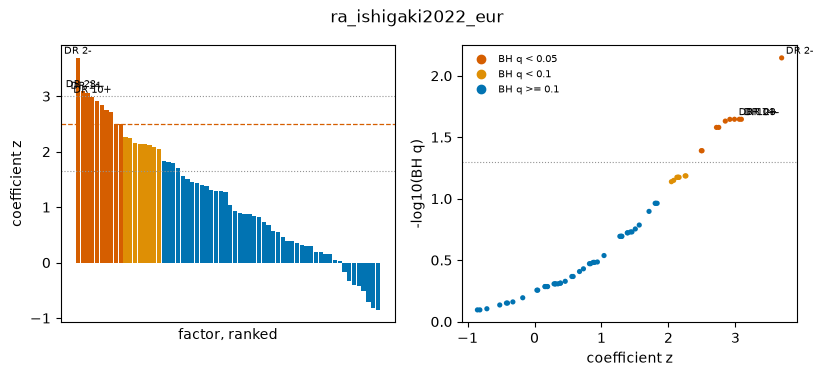

In [19]:
from scads_drvi.pl.enrichment import heritability_landscape

fig, _ = heritability_landscape(arm, trait="ra_ishigaki2022_eur", titles=embed_gpu.var["title"])
fig;

Both panels above rank the same factors, though -- the volcano's `-log10(q)` is a monotone, one-tailed function of the same z-score the bar chart already plots, so on a single trait the two panels are redundant. `latent_heatmap` below pairs that same heritability signal (an optional bar above the heatmap, with its own error bars and BH-significance colouring) with a genuinely different view instead -- which cells actually drive each enriched factor, split into its positive and negative direction by default (`directional=True`, matching `latent_umap_grid`'s own default -- every factor interpretability plot in this package shows split factors unless told not to) -- both directions' real S-LDSC z-scores are shown, not just the one this fit's top peaks happened to be scored under.

(`trait_concordance`, which compares this ranking against a second, independently-run trait, is deliberately not shown with real data here -- this tutorial runs one real S-LDSC sweep, against rheumatoid arthritis; a second real trait means a second multi-hour LDSC run. See its docstring/tests for a worked example.)

/allen/programs/celltypes/workgroups/hct/mike.cuoco/scads_drvi/.venv/lib/python3.13/site-packages/scanpy/plotting/_utils.py:509: ImplicitModificationWarning: Trying to modify attribute `._uns` of view, initializing view as actual.
  adata.uns[f"{value_to_plot}_colors"] = colors_list


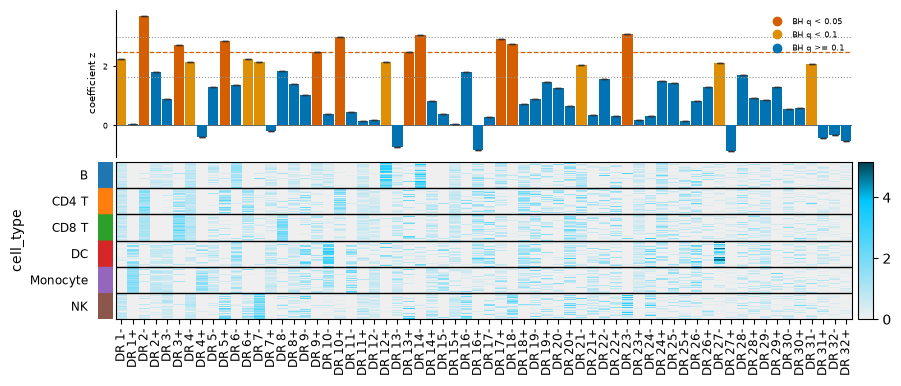

In [20]:
from scads_drvi.pl.factors import latent_heatmap

# Every dim x direction pair S-LDSC actually tested -- both directions now, keyed
# "{dim}+"/"{dim}-" the same way latent_heatmap's own directional split (the default,
# matching latent_umap_grid's own) names its columns, rather than picking one
# direction in advance the way a single-column-per-factor heatmap would have to.
signed = arm.assign(signed_dim=arm["dim"] + arm["direction"].map({"pos": "+", "neg": "-"}))
signed = signed.set_index("signed_dim")
embed_scored = embed_gpu[:, arm["dim"].unique()]

fig, _ = latent_heatmap(
    embed_scored, "cell_type",
    heritability=signed["Coefficient_z-score"], heritability_se=signed["Coefficient_std_error"],
    heritability_q=signed["fdr_q"],
)
fig;

## 4. Cell scores

A ReLU'd, direction-specific view of `embed.X` is the *only* place a positive/negative
split is ever materialized -- DRVI itself has none; `cs_from_z` folds each significant
factor's z-score-weighted loading into one per-cell score.


In [21]:
from scads_drvi.scores.cell import cs_from_z

# relu(X) -- the ONLY place a pos/neg split is ever materialized, derived on demand.
# embed_gpu (not the canonical embed) -- arm's factors are keyed to this GPU fit's own
# dims (keep_gpu), so the loadings scored against them must come from the same object.
loadings = pd.DataFrame(
    np.clip(embed_gpu.X, 0, None), index=embed_gpu.obs_names, columns=embed_gpu.var_names
)[keep_gpu]
# arm has one row per (factor, direction); cs_from_z needs one row per factor, so filter
# to the direction the loadings above are scoring -- "pos", to match.
pos_results = arm.query("direction == 'pos'")
scores = cs_from_z(loadings, pos_results, model="ra_ishigaki2022_eur", trait="ra_ishigaki2022_eur")

cells["score"] = scores.values.reindex(cells.index)
# Written onto the canonical `embed` (not embed_gpu) because that's the object with a
# computed UMAP for the plots below -- both share the same obs_names/cells either way.
embed.obs["score"] = cells["score"]
scores.label, scores.null

('$CS_i$ (z-weighted loading sum)', 0.0)

In [22]:
from scads_drvi.scores.aggregate import summarize_by

summarize_by(scores.values, cells, by=["cell_type"], min_cells=10)


GroupStats(frame=  cell_type     n  n_scored       mean     median       std       sem  \
0         B  1003      1003  12.649867  12.591482  3.306491  0.104404   
1     CD4 T  3303      3303  16.621685  16.150196  3.825676  0.066566   
2     CD8 T  1587      1587  14.513267  13.822255  3.925861  0.098548   
3        DC   343       343   6.223549   6.013763  2.180386  0.117730   
4  Monocyte  3863      3863   8.645047   8.428499  2.869524  0.046169   
5        NK  1467      1467  10.723265  10.145550  4.097808  0.106988   

      ci_low    ci_high  
0  12.445239  12.854495  
1  16.491217  16.752152  
2  14.320118  14.706417  
3   5.992803   6.454295  
4   8.554558   8.735536  
5  10.513571  10.932958  , keys=('cell_type',), value='cs', min_cells=10, n_dropped=0)

Now that a per-cell score exists, the same heatmap above can carry it too --
`cell_scores` is just another optional `latent_heatmap` argument, drawn as a bar to
the right (one per `cell_type` group, its own standard error included) alongside the
heritability bar already on top. Same figure as Section 3's, richer than the table
above.

/allen/programs/celltypes/workgroups/hct/mike.cuoco/scads_drvi/.venv/lib/python3.13/site-packages/scanpy/plotting/_utils.py:509: ImplicitModificationWarning: Trying to modify attribute `._uns` of view, initializing view as actual.
  adata.uns[f"{value_to_plot}_colors"] = colors_list


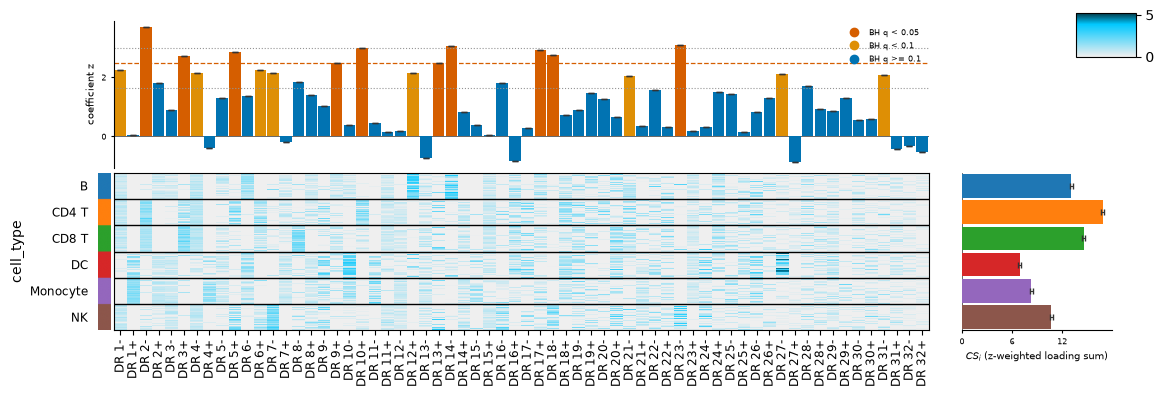

In [23]:
fig, _ = latent_heatmap(
    embed_scored, "cell_type",
    heritability=signed["Coefficient_z-score"], heritability_se=signed["Coefficient_std_error"],
    heritability_q=signed["fdr_q"], cell_scores=embed.obs["score"], cell_score_label=scores.label,
)
fig;

`cell_score_agg="sum"` instead of the default `"mean"` shows each group's raw,
non-normalised total instead of its per-cell average -- "non-normalised cell weights":
a large, modestly-scoring group can outweigh a small, high-scoring one here, the
opposite emphasis from the per-cell average above.

/allen/programs/celltypes/workgroups/hct/mike.cuoco/scads_drvi/.venv/lib/python3.13/site-packages/scanpy/plotting/_utils.py:509: ImplicitModificationWarning: Trying to modify attribute `._uns` of view, initializing view as actual.
  adata.uns[f"{value_to_plot}_colors"] = colors_list


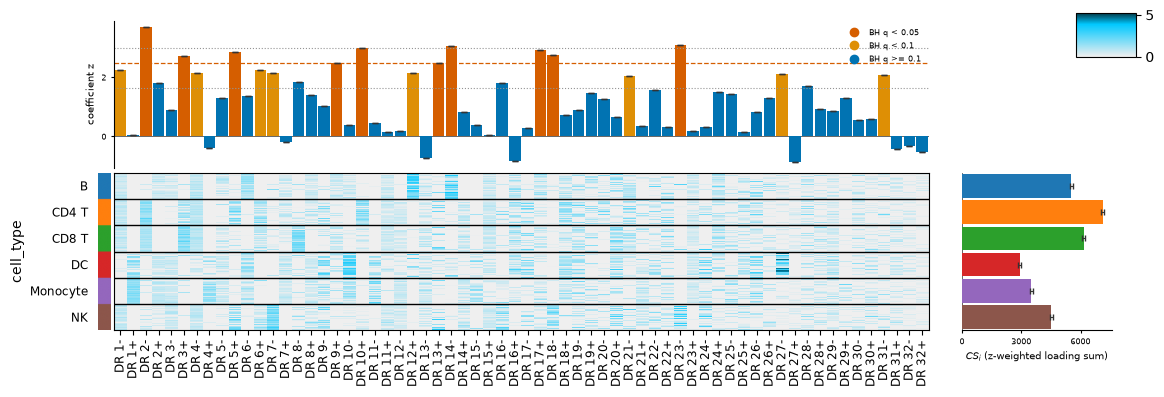

In [24]:
fig, _ = latent_heatmap(
    embed_scored, "cell_type",
    heritability=signed["Coefficient_z-score"], heritability_se=signed["Coefficient_std_error"],
    heritability_q=signed["fdr_q"], cell_scores=embed.obs["score"], cell_score_label=scores.label,
    cell_score_agg="sum",
)
fig;

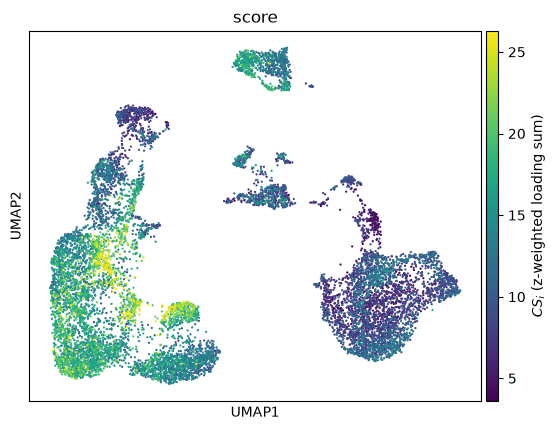

In [25]:
# A continuous embedding scatter is a scanpy call too -- vmin/vmax as scanpy's
# own percentile strings, matching scads_drvi.pl.color.ROBUST_LIMITS.
fig = sc.pl.embedding(
    embed, basis="umap", color="score", vmin="p1", vmax="p99.5",
    show=False, return_fig=True,
)
fig.axes[-1].set_ylabel(scores.label)
fig;

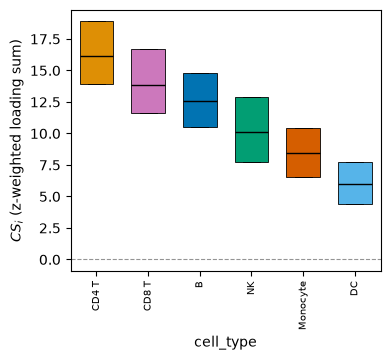

In [26]:
from scads_drvi.pl.enrichment import score_by_group
from scads_drvi.pl.frugal import box_stats

box_stats_frame = box_stats(cells["score"], cells["cell_type"].astype(str), min_n=10)
fig, _ = score_by_group(
    box_stats_frame, group_label="cell_type", value_label=scores.label, null=scores.null,
)
fig;

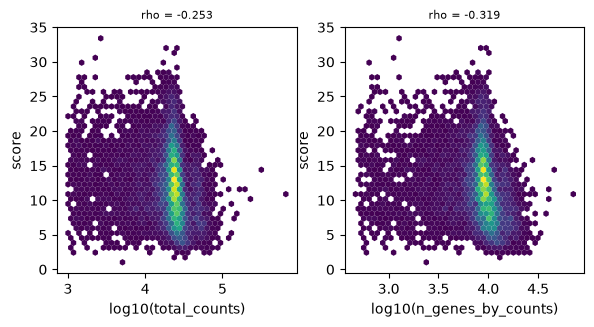

In [27]:
from scads_drvi.pl.enrichment import covariate_audit

# Does the score itself just track sequencing depth?
fig, _ = covariate_audit(
    cells, value="score", covariates=["total_counts", "n_genes_by_counts"],
    log_x=["total_counts", "n_genes_by_counts"],
)
fig;

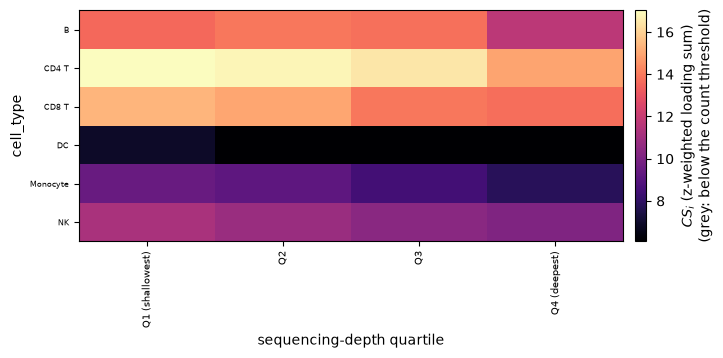

In [28]:
from scads_drvi.pl.enrichment import grouped_landscape
from scads_drvi.scores.aggregate import group_matrix

# A second, real grouping derived from the real per-cell depth -- not a second
# categorical obs column this dataset happens to carry.
cells["depth_quartile"] = pd.qcut(
    cells["total_counts"], 4, labels=["Q1 (shallowest)", "Q2", "Q3", "Q4 (deepest)"]
)
means, counts = group_matrix(
    scores.values, cells, index="cell_type", columns="depth_quartile", min_cells=10,
)
fig, _ = grouped_landscape(
    means, counts, row_label="cell_type", column_label="sequencing-depth quartile",
    value_label=scores.label,
)
fig;

## Where DRVI's own tools still take over

Every `pl.*` figure this package draws has been shown above: `latent_umap_grid` (a per-dimension embedding grid; a plain categorical or continuous embedding scatter is just `sc.pl.embedding` directly -- see above), `factor_correlation`/`factor_distributions`/`covariate_association`/`latent_dimension_stats`/`latent_heatmap` (factor diagnostics -- `latent_heatmap` itself optionally draws a per-dimension heritability bar above it and a per-group cell-score bar to its right, both with error bars, rather than a second `latent_heatmap_with_heritability`-style function), and `heritability_landscape`/`covariate_audit`/`score_by_group`/`grouped_landscape` (enrichment and scores) -- `latent_umap_grid`/`latent_dimension_stats`/`latent_heatmap` ported to match DRVI's own colours and mechanics exactly, wrapping `scanpy.pl.embedding` directly where an embedding is involved, needing no `drvi-py` install. (`trait_concordance` is the one figure not shown against real data here -- it compares two independently-run traits, and this tutorial only runs one.)

`latent_umap_grid` and `latent_heatmap` both default to `directional=True` -- every factor interpretability plot in this package shows split factors (each dimension's own +/- columns or panels) unless told not to (`directional=False`). `latent_heatmap`'s `cell_score_agg` also takes `"sum"` alongside the default `"mean"`/`"median"`, for a group's raw, non-normalised total rather than its per-cell average -- both shown in Section 4 above.

What genuinely still has no in-house equivalent is DRVI's own model-side interpretability: the model's `get_effect_of_splits_within_distribution`/`_out_of_distribution` (used above to rank each factor's top peaks) and `calculate_interpretability_scores`. `scads-drvi` wraps none of these a second time -- see the [DRVI docs](https://drvi.readthedocs.io/).